Building a MultiClass Image Classifier using CNN and MNIST Dataset
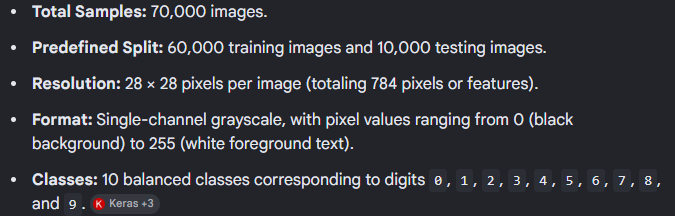

In [2]:
#importing necessary dependencies
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.datasets import mnist

In [3]:
from google.colab import files
from PIL import Image

In [5]:
#loading the MNIST Data
(x_train,y_train), (x_test,y_test)=mnist.load_data()

#MNIST keeps 60,000 images for training and 10,000 images for testing purposes

In [7]:
x_train.shape #60,000 images, each of dimention 28x28

(60000, 28, 28)

In [9]:
x_test.shape #10,000 images, each of dimention 28x28

(10000, 28, 28)

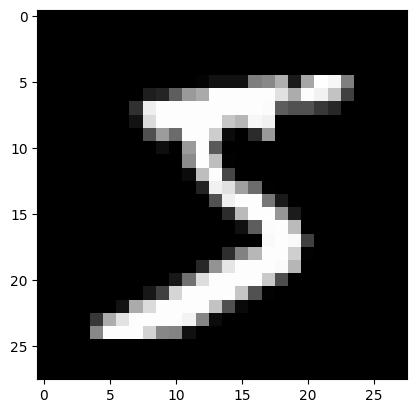

In [12]:
plt.imshow(x_train[0], cmap='gray')

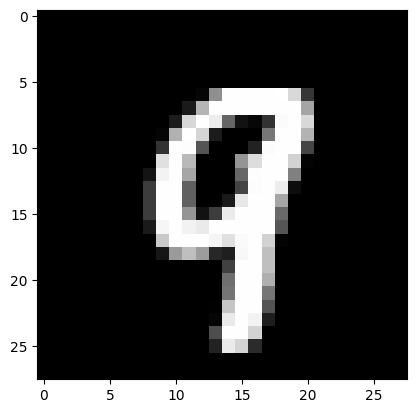

In [13]:
plt.imshow(x_train[800], cmap='gray')

In [14]:
sample_pixel=x_train[800]

In [15]:
print("Pixel representation of the image with 28x28 dimention",sample_pixel[:,:])

Pixel representation of the image with 28x28 dimention [[  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   6 143 254 254 254 254
  255 217  54   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0  26 181 254 254 254 254 254
  254 254 165   0   0   0   0   0   0   0]
 [  0   0

In [16]:
sample_pixel=x_train[2500]

In [17]:
print("Pixel representation of the image with 28x28 dimention",sample_pixel[:,:])

Pixel representation of the image with 28x28 dimention [[  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0  61 178 207  22   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   6 178 254 254  48  98 235 153
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0  14 254 254 179   8  71 254 253
  214  11   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0 120 254 254  60   0  12  77 231
  254 197  56   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0  43 222 254 239  23   0   0   0  51
  237 254 228  56   0   0   0   0   0   0]
 [  0   0

In [18]:
#normalizing the pixel values from [0-255] to [0-1]

x_train_norm=x_train.astype("float32")/255.0
x_test_norm=x_test.astype("float32")/255.0

In [19]:
normalized_pixel=x_train_norm[250]

In [20]:
print("Pixel representation of the image with 28x28 dimention",normalized_pixel[:,:])

Pixel representation of the image with 28x28 dimention [[0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.        ]
 [0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.        ]
 [0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.        ]
 [0.         0.         0.         0.         0.         0.
  0.         0.         

In [21]:
#performing convolution and pooling on top of a sample image and then doing it on the entire data
sample_image=x_train_norm[0:1] #taking the first image as our sample image with dimention 28x28

In [22]:
sample_conv=layers.Conv2D(filters=4, kernel_size=(3,3), activation='relu')

In [23]:
sample_pool=layers.MaxPooling2D(pool_size=(2,2)) #this pool size is same as window size 2x2

In [24]:
sample_image=np.expand_dims(sample_image,axis=-1)

In [25]:
conv_output=sample_conv(sample_image)
#n=28, f=3, so n-f+1 = 26x26
#dimention of feature map or the conv_output will be 26x26 represented as - [1,26,26,4] here 4 represents 4 filters

In [27]:
pool_output=sample_pool(conv_output) #here since window size is 2x2, output dimention becomes 13x13

In [28]:
conv_output.shape

TensorShape([1, 26, 26, 4])

In [29]:
pool_output.shape

TensorShape([1, 13, 13, 4])

In [30]:
flatten_output=layers.Flatten()(pool_output)

In [32]:
flatten_output.shape #here 13x13x4 = 676 values
#[x1,x2,x3,.........x676] long array that gets passed to the NN Input layer

TensorShape([1, 676])

In [33]:
#Building the CNN Image Classifier
model=models.Sequential([
    layers.Input(shape=(28,28,1),name = "input_layer"),
    layers.Conv2D(filters=16, kernel_size=(3,3), activation='relu',name = "conv_layer_1"),
    layers.MaxPooling2D(pool_size=(2,2),name = "pooling_layer_1"), #output dimention - [1,13,13,16] = 2704 values
    layers.Conv2D(filters=32, kernel_size=(3,3), activation='relu',name = "conv_layer_2"),
    layers.MaxPooling2D(pool_size=(2,2),name = "pooling_layer_2"), #output dimention - [1,6,6,32] = 1152 values
    layers.Flatten(name = "flatten_layer"), #output dimention - [1,1152] = 1152 values
    layers.Dense(units=64, activation='relu',name = "hiddenlayer_1"),
    layers.Dense(units=32, activation='relu',name = "hiddenlayer_2"),
    layers.Dense(units=10, activation='softmax',name = "output_layer") #10 neurons because we have 10 unique classes
])

In [34]:
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

In [38]:
model.fit(x_train_norm,y_train,epochs=20)

Epoch 1/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 33s 17ms/step - accuracy: 0.8401 - loss: 0.4773
Epoch 2/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 33s 17ms/step - accuracy: 0.9678 - loss: 0.1072
Epoch 3/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 32s 17ms/step - accuracy: 0.9756 - loss: 0.0794
Epoch 4/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 31s 16ms/step - accuracy: 0.9803 - loss: 0.0638
Epoch 5/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 31s 16ms/step - accuracy: 0.9839 - loss: 0.0533
Epoch 6/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 33s 17ms/step - accuracy: 0.9866 - loss: 0.0442
Epoch 7/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 41s 17ms/step - accuracy: 0.9880 - loss: 0.0376
Epoch 8/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 31s 17ms/step - accuracy: 0.9894 - loss: 0.0323
Epoch 9/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 31s 17ms/step - accuracy: 0.9908 - loss: 0.0288
Epoch 10/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 41s 17ms/step - accuracy: 0.9924 - loss: 0.0237
Epoch 11/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 32s 17ms/step - accuracy: 0.9923 - loss: 0.0222
Epoch 12

In [39]:
test_loss,test_accuracy=model.evaluate(x_test_norm,y_test)
print("test accuracy",test_accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9876 - loss: 0.0650
test accuracy 0.9876000285148621


In [66]:
upload=files.upload()

Saving 8.png to 8.png


In [67]:
image_path=list(upload.keys())[0]

In [68]:
img=Image.open(image_path)

In [69]:
#converting the image into greyscale
img=img.convert("L")

In [70]:
img=img.resize((28,28))

In [71]:
img_array=np.array(img)

In [72]:
print(img_array)

[[ 55  54  53  53  52  51  49  49  47  47  45  44  43  42  40  40  38  38
   37  37  36  36  35  35  35  34  33  44]
 [ 31  29  29  29  29  29  29  29  29  30  30  30  30  30  30  30  30  30
   30  30  30  31  31  31  31  31  30  40]
 [ 36  31  31  31  31  31  31  31  31  31  28  26  27  30  31  31  31  31
   31  31  31  31  31  31  31  31  30  38]
 [ 37  30  31  31  31  31  31  31  27  29  59  76  65  38  24  29  31  31
   31  31  31  31  31  31  31  31  31  37]
 [ 40  30  31  31  31  31  31  26  62 144 133 111 125 147 117  43  25  31
   31  31  31  31  31  31  31  31  31  35]
 [ 43  30  31  31  31  31  27  63 163  65  25  24  24  37  98 162  74  25
   31  31  31  31  31  31  31  31  31  33]
 [ 43  30  31  31  31  31  25 144  84  22  31  31  31  30  23  54 169  68
   27  31  31  31  31  31  31  31  31  31]
 [ 44  30  31  31  31  31  26 154  65  27  31  31  31  31  31  23  80 157
   27  31  31  31  31  31  31  31  31  31]
 [ 44  30  31  31  31  31  24 112 115  22  31  31  31  31  31  2

In [73]:
image_array=img_array/255.0

In [74]:
input_image=image_array.reshape(1,28,28,1)

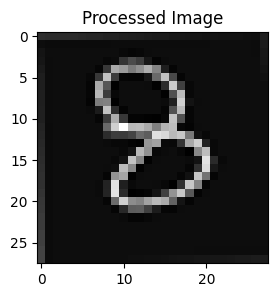

In [75]:
plt.figure(figsize=(5,3))
plt.imshow(input_image.squeeze(),cmap='gray')
plt.title("Processed Image")
plt.show()

In [76]:
prediction=model.predict(input_image)
predicted_digit=np.argmax(prediction)
print("Predicted Digit:",predicted_digit)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
Predicted Digit: 8
